# Análise anual de talhões (substituto do script Google Earth Engine)

Este notebook reproduz — em uma infraestrutura **gratuita** e **fora do Google Earth Engine** — o fluxo do seu script GEE original: recebe a geometria de um talhão (colada como GeoJSON/WKT ou enviada como arquivo `.geojson`/`.kml`/`.wkt`), busca a imagem de satélite **menos nublada de cada ano** e permite a interpretação visual para identificar o **ano de colheita**, registrando o resultado em uma planilha (CSV/Excel).

**Fonte de dados:** [Microsoft Planetary Computer](https://planetarycomputer.microsoft.com/) via STAC — acesso **anônimo** (sem login nem chave de API), com a coleção `landsat-c2-l2` cobrindo de forma contínua **1984 até hoje** (Landsat 4/5/7/8/9).

## Como a imagem de cada ano é escolhida

Diferente de uma composição por mediana com máscara de nuvem pixel a pixel, este notebook usa uma abordagem mais simples (e mais parecida com o "escolher a imagem mais limpa do ano" que se faz manualmente): para cada ano, busca todas as cenas disponíveis e seleciona diretamente a que tiver a **menor cobertura de nuvem** (`eo:cloud_cover`) reportada pelo próprio satélite — sem aplicar nenhuma máscara de nuvem pixel a pixel.

A visualização usa a mesma combinação de bandas do script GEE original — **falsa cor NIR / SWIR1 / RED** — mas com uma **janela de contraste fixa** (reflectância mínima = 0, máxima = 0.5), em vez de um realce por percentil calculado a cada imagem. Isso deixa o brilho comparável de ano para ano, útil para notar visualmente a queda de vigor da vegetação (colheita).

## Principais melhorias em relação ao script GEE original

1. **Fonte única e contínua** (Landsat Collection 2 Level 2 — reflectância de superfície) para toda a série de anos, com fator de escala oficial do USGS (`reflectância = DN × 0.0000275 − 0.2`).
2. **Sugestão automática de ano de colheita** via queda de NDVI ano a ano, para que você não precise olhar manualmente todas as imagens de cada talhão — o visor já abre no ano mais provável.
3. **Suporte a KML e WKT**, além de GeoJSON, como pedido — incluindo detecção do sistema de coordenadas (`crs`) quando presente no arquivo.
4. **Seleção da cena menos nublada por busca direta**, sem depender de filtros de nuvem na própria consulta STAC (que podem falhar silenciosamente ou descartar o ano inteiro em períodos de nebulosidade persistente, como ocorreu no RS em 2024).

In [ ]:
# para limpar o cache de composições (útil para forçar a recomposição das imagens)
import shutil
shutil.rmtree("cache_composicoes", ignore_errors=True)

In [1]:
import sys
sys.path.insert(0, ".")

import concurrent.futures
import json
import pickle
from pathlib import Path

import geopandas as gpd
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display

from geometria_utils import carregar_geojson_texto, carregar_arquivo_geometria, buffer_metros
from composicao_anual import composicao_anual, calcular_ndvi, aplicar_janela_fixa
from deteccao_colheita import serie_temporal_ndvi_medio, sugerir_anos_candidatos, RegistroColheitas

CACHE_DIR = Path("cache_composicoes")
CACHE_DIR.mkdir(exist_ok=True)


## 1. Informe a geometria do talhão\n\nCole um GeoJSON, cole um WKT (informando o EPSG de origem, já que WKT não guarda a projeção) **ou** envie um arquivo `.geojson`/`.kml`/`.wkt`.

In [2]:
modo_entrada = widgets.ToggleButtons(
    options=[
        ("Colar GeoJSON", "geojson_texto"),
        ("Colar WKT", "wkt_texto"),
        ("Enviar arquivo (.geojson/.kml/.wkt)", "arquivo"),
    ],
    description="Entrada:",
)

texto_geojson = widgets.Textarea(
    placeholder='Cole aqui o GeoJSON do talhão (FeatureCollection, Feature ou geometria)',
    layout=widgets.Layout(width="100%", height="120px"),
)

texto_wkt = widgets.Textarea(
    placeholder='Cole aqui o WKT do talhão (ex.: MULTIPOLYGON Z (((x y z, ...))))',
    layout=widgets.Layout(width="100%", height="120px"),
)

# O WKT não guarda a projeção junto do texto — é obrigatório informar o EPSG de origem.
# EPSG:5880 = SIRGAS 2000 / Brasil Polyconic (coordenadas na casa dos milhões,
# com falso Easting 5.000.000 e falso Northing 10.000.000 - caso comum de export do QGIS/ArcGIS).
crs_origem_wkt = widgets.Text(
    value="EPSG:5880",
    description="CRS do WKT:",
    style={"description_width": "initial"},
)

upload_arquivo = widgets.FileUpload(accept=".geojson,.json,.kml,.wkt", multiple=False)

campo_id_talhao = widgets.Text(value="id", description="Campo ID:", style={"description_width": "initial"})

painel_entrada = widgets.VBox([
    modo_entrada,
    widgets.HBox([texto_geojson, texto_wkt, upload_arquivo]),
    crs_origem_wkt,
    campo_id_talhao,
])
display(painel_entrada)


## 2. Carregar o(s) talhão(ões) a partir da seleção acima

In [3]:
def carregar_talhoes_selecionados():
    """Lê a seleção feita nos widgets acima e devolve a lista de
    (talhao_id, geometria) já em WGS84."""
    if modo_entrada.value == "geojson_texto":
        if not texto_geojson.value.strip():
            raise ValueError("Cole um GeoJSON na caixa de texto antes de continuar.")
        return carregar_geojson_texto(texto_geojson.value, id_campo=campo_id_talhao.value)

    if modo_entrada.value == "wkt_texto":
        if not texto_wkt.value.strip():
            raise ValueError("Cole um WKT na caixa de texto antes de continuar.")
        from geometria_utils import carregar_wkt_texto
        return carregar_wkt_texto(
            texto_wkt.value,
            crs_origem=crs_origem_wkt.value,
            id_campo=campo_id_talhao.value,
            propriedades={campo_id_talhao.value: "talhao_wkt_01"},
        )

    if not upload_arquivo.value:
        raise ValueError("Envie um arquivo .geojson, .kml ou .wkt antes de continuar.")

    item_upload = list(upload_arquivo.value.values())[0]
    nome_original = item_upload["metadata"]["name"]
    caminho_tmp = Path(f"/tmp/{nome_original}")
    caminho_tmp.write_bytes(item_upload["content"])
    return carregar_arquivo_geometria(
        caminho_tmp, id_campo=campo_id_talhao.value, crs_origem=crs_origem_wkt.value
    )


talhoes = carregar_talhoes_selecionados()
print(f"{len(talhoes)} talhão(ões) carregado(s): {[t[0] for t in talhoes]}")


1 talhão(ões) carregado(s): ['talhao_wkt_01']


## 3. Parâmetros da série temporal

Ajuste o intervalo de anos, a fonte de imagem e o buffer de contexto ao redor do talhão.

In [4]:
ANO_INICIO = 1991
ANO_FIM = 2026
ANO_TRANSICAO_SENTINEL = 2016  # a partir deste ano usa Sentinel-2 (mais detalhe); antes disso usa Landsat
BUFFER_METROS = 60             # margem ao redor do talhão, para dar contexto visual na interpretação
RESOLUCAO_LANDSAT_METROS = 30
RESOLUCAO_SENTINEL2_METROS = 10
# (não há mais filtro de nuvem: o notebook sempre usa a cena com a
#  menor cobertura de nuvem disponível em cada ano)


def fonte_e_resolucao_do_ano(ano):
    """Define automaticamente a fonte de imagem: Sentinel-2 (mais
    detalhe, 10 m) para os anos recentes, Landsat (cobre desde 1984,
    30 m) para os anos mais antigos, onde o Sentinel-2 ainda não existia."""
    if ano >= ANO_TRANSICAO_SENTINEL:
        return "sentinel2", RESOLUCAO_SENTINEL2_METROS
    return "landsat", RESOLUCAO_LANDSAT_METROS


## 4. Funções de processamento (busca STAC + cache em disco)

O cache evita repetir a busca/download de cenas já processadas em sessões anteriores.

In [5]:
def caminho_cache(talhao_id, ano, fonte):
    nome = f"{talhao_id}_{ano}_{fonte}.pkl".replace("/", "_").replace(" ", "_")
    return CACHE_DIR / nome


def processar_talhao(talhao_id, geometria, ano_inicio=ANO_INICIO, ano_fim=ANO_FIM,
                      buffer_m=BUFFER_METROS, usar_cache=True, max_workers=6):
    """
    Para um talhão, monta a composição anual de cada ano do intervalo,
    alternando automaticamente a fonte de imagem por ano (Sentinel-2 nos
    anos recentes, Landsat nos mais antigos — ver `fonte_e_resolucao_do_ano`).

    Os anos que ainda não estão em cache são buscados em PARALELO (até
    `max_workers` ao mesmo tempo) — como o tempo é dominado por espera de
    rede (busca STAC + download dos pixels), paralelizar reduz bastante
    o tempo total em comparação a buscar um ano de cada vez. Se você
    tomar erros de limite de requisições (HTTP 429) do Planetary
    Computer, reduza `max_workers`.

    Usa um cache em disco (pickle) para não repetir buscas já feitas em
    sessões anteriores. Retorna {ano: composicao_xarray|None}.
    """
    geometria_buffer = buffer_metros(geometria, buffer_m)
    composicoes = {}
    anos_para_buscar = []

    for ano in range(ano_inicio, ano_fim + 1):
        fonte, _ = fonte_e_resolucao_do_ano(ano)
        arquivo_cache = caminho_cache(talhao_id, ano, fonte)
        if usar_cache and arquivo_cache.exists():
            with open(arquivo_cache, "rb") as f:
                composicoes[ano] = pickle.load(f)
        else:
            anos_para_buscar.append(ano)

    def _buscar_um_ano(ano):
        fonte, resolucao = fonte_e_resolucao_do_ano(ano)
        try:
            composicao = composicao_anual(
                geometria, ano,
                geometria_buffer_wgs84=geometria_buffer,
                fonte=fonte, resolucao=resolucao,
            )
        except Exception as erro:
            print(f"[{talhao_id} - {ano}] erro ao processar ({fonte}): {erro}")
            composicao = None
        return ano, fonte, composicao

    if anos_para_buscar:
        print(f"Buscando {len(anos_para_buscar)} ano(s) em paralelo (até {max_workers} por vez)...")
        with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
            for ano, fonte, composicao in executor.map(_buscar_um_ano, anos_para_buscar):
                composicoes[ano] = composicao
                if usar_cache:
                    with open(caminho_cache(talhao_id, ano, fonte), "wb") as f:
                        pickle.dump(composicao, f)

    return composicoes


## 5. Visor interativo: slider de ano + candidatos automáticos + formulário de registro

In [9]:
def montar_visor_talhao(talhao_id, geometria, composicoes, registro):
    """
    Monta a interface interativa para um único talhão: a partir de um
    dicionário {ano: composicao} já processado (ver `processar_talhao`),
    sugere candidatos a colheita via queda de NDVI, e mostra um visor com
    slider de ano + imagem em falsa cor (NIR/SWIR1/RED) + formulário para
    registrar o ano de colheita identificado.
    """
    serie_ndvi = serie_temporal_ndvi_medio(composicoes)
    candidatos = sugerir_anos_candidatos(serie_ndvi)

    anos_com_imagem = sorted([ano for ano, c in composicoes.items() if c is not None])
    if not anos_com_imagem:
        print(f"Nenhuma imagem válida encontrada para o talhão '{talhao_id}' no período.")
        return

    if candidatos:
        print("Candidatos automáticos a ano de colheita (maior queda de NDVI primeiro):")
        for c in candidatos:
            print(f"  - {c['ano']}: NDVI caiu de {c['ndvi_antes']} para {c['ndvi_depois']} (queda de {c['queda_ndvi']})")
    else:
        print("Nenhuma queda de NDVI acima do limiar foi encontrada — revise manualmente a série completa.")

    slider_ano = widgets.SelectionSlider(
        options=anos_com_imagem,
        value=candidatos[0]["ano"] if candidatos else anos_com_imagem[0],
        description="Ano:",
        continuous_update=False,
    )
    saida_imagem = widgets.Output()
    campo_ano_colheita = widgets.Dropdown(
        options=["Não identificado"] + anos_com_imagem,
        description="Ano da colheita:",
        style={"description_width": "initial"},
    )
    campo_confianca = widgets.Dropdown(
        options=["alta", "media", "baixa"],
        description="Confiança:",
    )
    campo_obs = widgets.Text(description="Observações:", style={"description_width": "initial"})
    botao_salvar = widgets.Button(description="Salvar na planilha", button_style="success")
    saida_status = widgets.Output()

    def atualizar_imagem(change=None):
        with saida_imagem:
            saida_imagem.clear_output(wait=True)
            ano = slider_ano.value
            composicao = composicoes[ano]
            rgb = aplicar_janela_fixa(composicao, bandas=("nir", "swir1", "red"), minimo=0.0, maximo=0.5)
            fonte = composicao.attrs.get("fonte", "?")
            nuvem_pct = composicao.attrs.get("nuvem_pct")
            tier = composicao.attrs.get("tier")
            info_nuvem = f", {nuvem_pct:.0f}% nuvem" if nuvem_pct is not None else ""
            aviso_tier = " ⚠️ T2: geolocalização pode estar imprecisa" if tier == "T2" else ""
            plt.figure(figsize=(6, 6))
            plt.imshow(rgb)
            plt.title(f"Talhão {talhao_id} - {ano} ({fonte}{info_nuvem}, janela 0-0.5){aviso_tier}", fontsize=9)
            plt.axis("off")
            plt.show()

    def salvar(botao=None):
        with saida_status:
            saida_status.clear_output()
            if campo_ano_colheita.value == "Não identificado":
                print("Selecione um ano de colheita antes de salvar (ou marque como 'não identificado' de propósito).")
            registro.registrar(
                talhao_id=talhao_id,
                ano_colheita=campo_ano_colheita.value,
                confianca_visual=campo_confianca.value,
                observacoes=campo_obs.value,
            )
            print(f"Registrado: talhão={talhao_id}, ano_colheita={campo_ano_colheita.value} -> {registro.caminho_csv}")

    slider_ano.observe(atualizar_imagem, names="value")
    botao_salvar.on_click(salvar)

    atualizar_imagem()
    display(widgets.VBox([
        slider_ano,
        saida_imagem,
        widgets.HBox([campo_ano_colheita, campo_confianca]),
        campo_obs,
        botao_salvar,
        saida_status,
    ]))


## 5b. Visualização em grade (todos os anos de uma vez)

Mostra todas as imagens do período lado a lado (3 colunas por linha), com o contorno do talhão sobreposto (borda preta, interior transparente) para conferir o enquadramento em cada ano.

In [6]:
def plotar_grade_anual(talhao_id, geometria, composicoes,
                        bandas=("nir", "swir1", "red"), minimo=0.0, maximo=0.5, ncols=3):
    """
    Plota uma imagem por ano (falsa cor NIR/SWIR1/RED, janela fixa 0-0.5),
    lado a lado em uma grade de `ncols` colunas, com o contorno do talhão
    sobreposto em cada uma (borda preta, interior transparente). O número
    de linhas se ajusta automaticamente à quantidade de anos com imagem.
    """
    anos_com_imagem = sorted([ano for ano, comp in composicoes.items() if comp is not None])
    if not anos_com_imagem:
        print(f"Nenhuma imagem válida encontrada para o talhão '{talhao_id}' no período.")
        return

    n = len(anos_com_imagem)
    nrows = int(np.ceil(n / ncols))

    fig, eixos = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows), squeeze=False)

    # Reprojeta o talhão apenas uma vez por CRS distinto (normalmente todas
    # as imagens do mesmo talhão caem no mesmo fuso UTM, então isso evita
    # repetir a mesma reprojeção a cada imagem da grade).
    talhao_por_crs = {}

    for i, ano in enumerate(anos_com_imagem):
        linha, coluna = divmod(i, ncols)
        ax = eixos[linha][coluna]

        composicao = composicoes[ano]
        rgb = aplicar_janela_fixa(composicao, bandas=bandas, minimo=minimo, maximo=maximo)

        # As coordenadas x/y do stackstac são o CENTRO de cada pixel, não a
        # borda — por isso somamos/subtraímos meio pixel para chegar na
        # borda real. Sem isso, a imagem fica desenhada meio pixel deslocada
        # (e um pixel inteiro mais "espremida") em relação ao chão real,
        # fazendo o contorno do talhão parecer deslocado.
        dx = abs(float(composicao.x[1] - composicao.x[0]))
        dy = abs(float(composicao.y[0] - composicao.y[1]))
        extent = [
            float(composicao.x.min()) - dx / 2, float(composicao.x.max()) + dx / 2,
            float(composicao.y.min()) - dy / 2, float(composicao.y.max()) + dy / 2,
        ]
        ax.imshow(rgb, extent=extent, origin="upper")

        # Sobrepõe o contorno do talhão, reprojetado para o CRS (UTM) da
        # imagem (usa o cache por CRS em vez de reprojetar de novo)
        crs_imagem = str(composicao.rio.crs)
        if crs_imagem not in talhao_por_crs:
            talhao_por_crs[crs_imagem] = gpd.GeoSeries([geometria], crs="EPSG:4326").to_crs(composicao.rio.crs)
        talhao_por_crs[crs_imagem].plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.5)

        fonte = composicao.attrs.get("fonte", "?")
        nuvem_pct = composicao.attrs.get("nuvem_pct")
        tier = composicao.attrs.get("tier")
        #info_nuvem = f", {nuvem_pct:.0f}% nuvem" if nuvem_pct is not None else ""
        aviso_tier = " ⚠️ T2 (geolocalização pode estar imprecisa)" if tier == "T2" else ""
        ax.set_title(f"{ano} ({fonte})", fontsize=12)
        ax.set_xticks([])
        ax.set_yticks([])

    # Esconde os eixos sobrando quando o total não é múltiplo de `ncols`
    for j in range(n, nrows * ncols):
        linha, coluna = divmod(j, ncols)
        eixos[linha][coluna].axis("off")

    #fig.suptitle(f"Talhão {talhao_id} — falsa cor NIR/SWIR1/RED (janela {minimo}-{maximo})", fontsize=14)
    plt.tight_layout()
    plt.show()


## 6. Executar para o primeiro talhão carregado

Processando série temporal do talhão 'talhao_wkt_01' (isso pode levar alguns minutos)...
Buscando 36 ano(s) em paralelo (até 6 por vez)...


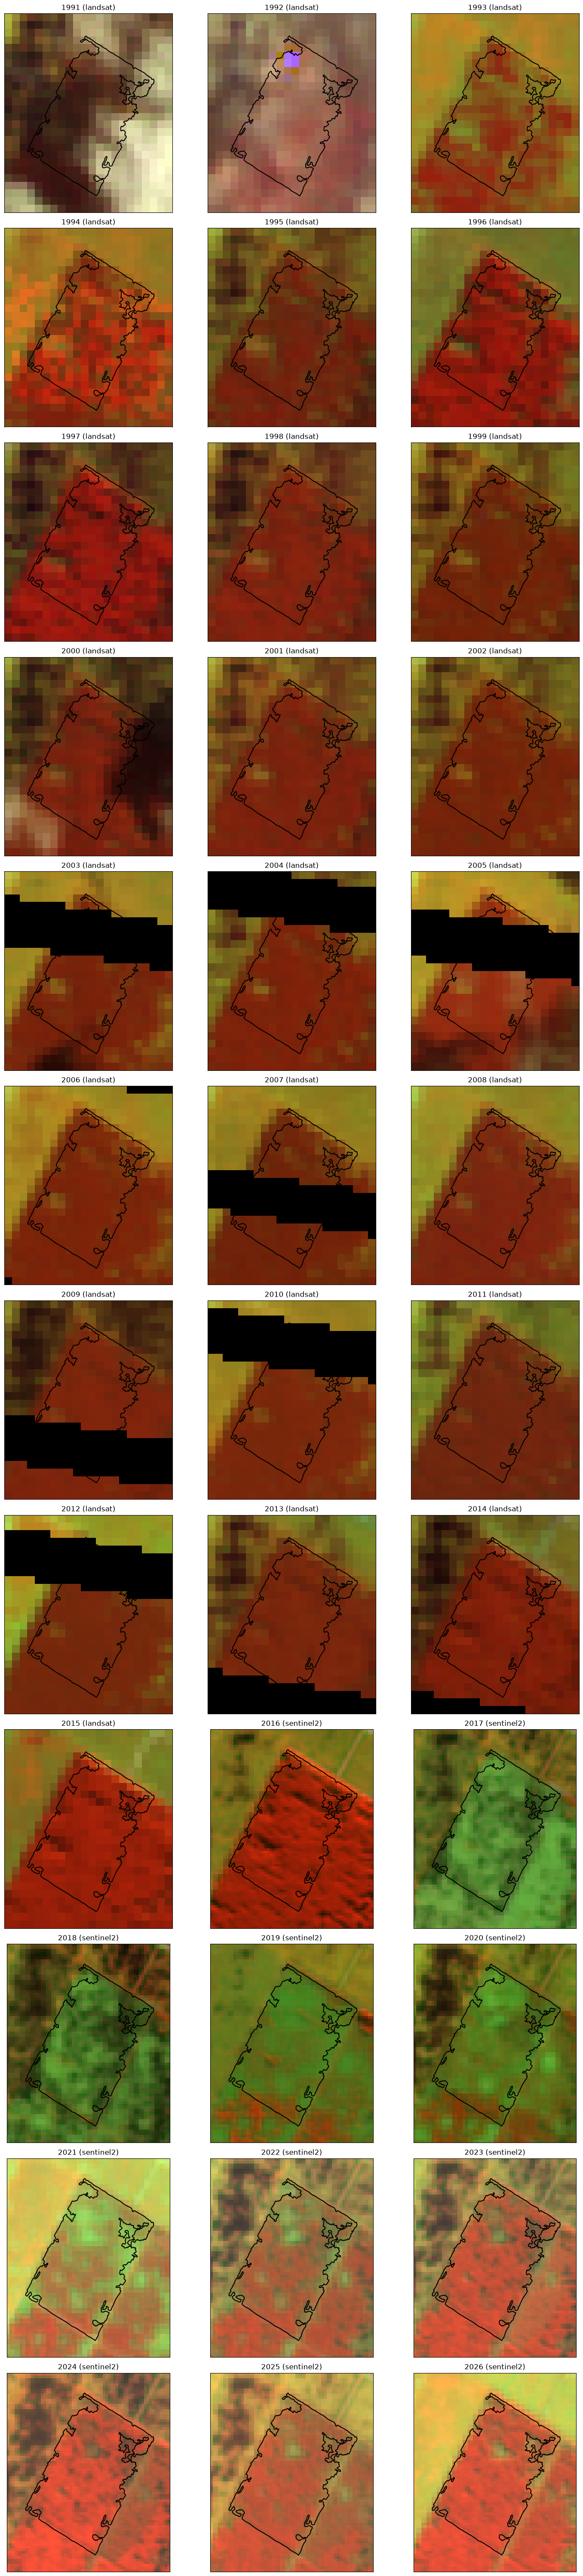

In [7]:
#registro = RegistroColheitas("colheitas_identificadas.csv")

talhao_id, geometria = talhoes[0]

print(f"Processando série temporal do talhão '{talhao_id}' (isso pode levar alguns minutos)...")
composicoes = processar_talhao(talhao_id, geometria)

plotar_grade_anual(talhao_id, geometria, composicoes)
#montar_visor_talhao(talhao_id, geometria, composicoes, registro)


In [ ]:
registro = RegistroColheitas("colheitas_identificadas.csv")
montar_visor_talhao(talhao_id, geometria, composicoes, registro)


Candidatos automáticos a ano de colheita (maior queda de NDVI primeiro):
  - 2017: NDVI caiu de 0.829 para 0.38 (queda de 0.448)
  - 2021: NDVI caiu de 0.591 para 0.386 (queda de 0.205)


## 7. (Opcional) Processar todos os talhões de uma vez

Se seu GeoJSON/KML tiver várias feições (vários talhões), mude `executar_todos_os_talhoes` para `True` na célula abaixo para abrir o visor de cada um em sequência.

In [ ]:
executar_todos_os_talhoes = False  # mude para True para percorrer todos de uma vez

if executar_todos_os_talhoes:
    for talhao_id, geometria in talhoes:
        print(f"Processando série temporal do talhão '{talhao_id}' (isso pode levar alguns minutos)...")
        composicoes = processar_talhao(talhao_id, geometria)
        plotar_grade_anual(talhao_id, geometria, composicoes)
        montar_visor_talhao(talhao_id, geometria, composicoes, registro)


## Planilha final

A cada clique em **"Salvar na planilha"**, a planilha `colheitas_identificadas.csv` é atualizada imediatamente (não perde progresso se o notebook fechar). Para exportar em Excel:

```python
registro.exportar_excel("colheitas_identificadas.xlsx")
```
